In [1]:
from torchvision.datasets import ImageFolder
from pathlib import Path

dataset_path = Path("../data/raw/EuroSAT")

dataset = ImageFolder(dataset_path)

print(len(dataset))
print(dataset.classes)

27000
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [2]:
labels = dataset.targets

In [3]:
from sklearn.model_selection import train_test_split

indices = list(range(len(dataset)))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

temp_labels = [labels[i] for i in temp_idx]

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

In [4]:
from pathlib import Path
import pandas as pd

DATASET_ROOT = Path("../data/raw/EuroSAT")

samples = dataset.samples

image_paths = [
    Path(path).relative_to(DATASET_ROOT).as_posix()
    for path, _ in samples
]

labels = [label for _, label in samples]

In [5]:
print(image_paths[:5])
print(labels[:5])

['AnnualCrop/AnnualCrop_1.jpg', 'AnnualCrop/AnnualCrop_10.jpg', 'AnnualCrop/AnnualCrop_100.jpg', 'AnnualCrop/AnnualCrop_1000.jpg', 'AnnualCrop/AnnualCrop_1001.jpg']
[0, 0, 0, 0, 0]


In [6]:
train_df = pd.DataFrame({
    "image_path": [image_paths[i] for i in train_idx],
    "label": [labels[i] for i in train_idx]
})

val_df = pd.DataFrame({
    "image_path": [image_paths[i] for i in val_idx],
    "label": [labels[i] for i in val_idx]
})

test_df = pd.DataFrame({
    "image_path": [image_paths[i] for i in test_idx],
    "label": [labels[i] for i in test_idx]
})

In [7]:
idx_to_class = {
    idx: cls
    for cls, idx in dataset.class_to_idx.items()
}

train_df["class_name"] = train_df["label"].map(idx_to_class)
val_df["class_name"] = val_df["label"].map(idx_to_class)
test_df["class_name"] = test_df["label"].map(idx_to_class)

In [8]:
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

train_df.to_csv(processed_dir / "train.csv", index=False)
val_df.to_csv(processed_dir / "validation.csv", index=False)
test_df.to_csv(processed_dir / "test.csv", index=False)

print("CSV files saved successfully!")

CSV files saved successfully!


In [9]:
print(f"Train      : {len(train_df)}")
print(f"Validation : {len(val_df)}")
print(f"Test       : {len(test_df)}")

Train      : 21600
Validation : 2700
Test       : 2700


In [10]:
def show_distribution(df, name):
    print(f"\n{name}")
    print(df["class_name"].value_counts().sort_index())

show_distribution(train_df, "Training")
show_distribution(val_df, "Validation")
show_distribution(test_df, "Testing")


Training
class_name
AnnualCrop              2400
Forest                  2400
HerbaceousVegetation    2400
Highway                 2000
Industrial              2000
Pasture                 1600
PermanentCrop           2000
Residential             2400
River                   2000
SeaLake                 2400
Name: count, dtype: int64

Validation
class_name
AnnualCrop              300
Forest                  300
HerbaceousVegetation    300
Highway                 250
Industrial              250
Pasture                 200
PermanentCrop           250
Residential             300
River                   250
SeaLake                 300
Name: count, dtype: int64

Testing
class_name
AnnualCrop              300
Forest                  300
HerbaceousVegetation    300
Highway                 250
Industrial              250
Pasture                 200
PermanentCrop           250
Residential             300
River                   250
SeaLake                 300
Name: count, dtype: int64


In [11]:
train_df.head()

,image_path,label,class_name
0,AnnualCrop/AnnualCrop_1556.jpg,0,AnnualCrop
1,PermanentCrop/PermanentCrop_1345.jpg,6,PermanentCrop
2,SeaLake/SeaLake_2922.jpg,9,SeaLake
3,SeaLake/SeaLake_1202.jpg,9,SeaLake
4,Residential/Residential_1228.jpg,7,Residential


### Making Pytorch importable

In [12]:
from pathlib import Path

import pandas as pd

from PIL import Image

from torch.utils.data import Dataset

In [13]:
class EuroSATDataset(Dataset):

    def __init__(
        self,
        csv_file,
        root_dir,
        transform=None
    ):

        self.data = pd.read_csv(csv_file)

        self.root_dir = Path(root_dir)

        self.transform = transform

    def __len__(self):

        return len(self.data)

    
    def __getitem__(self, idx):

        row = self.data.iloc[idx]

        image_path = self.root_dir / row["image_path"]

        image = Image.open(image_path).convert("RGB")

        label = row["label"]

        if self.transform:

            image = self.transform(image)

        return {
                "image": image,
                "label": label,
                "class_name": row["class_name"],
                "image_path": row["image_path"]
            }

In [14]:
dataset = EuroSATDataset(
    csv_file="../data/processed/train.csv",
    root_dir="../data/raw/EuroSAT"
)

In [15]:
print(len(dataset))

21600


In [16]:
image, label,class_name, image_path = dataset[0]
print(type(image), label)
print(class_name)
print(image_path)

<class 'str'> label
class_name
image_path


### Image transformers for passing through the LeNet,AlexNet, VGG18, GoogLeNet, ResNet,EfficientNet

In [17]:
from torchvision import transforms

In [18]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomVerticalFlip(p=0.5),

    transforms.RandomRotation(20),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [19]:
test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [20]:
dataset = EuroSATDataset(
    csv_file="../data/processed/train.csv",
    root_dir="../data/raw/EuroSAT",
    transform=train_transform
)

In [21]:
sample = dataset[0]

print(sample["image"].shape)

torch.Size([3, 224, 224])


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

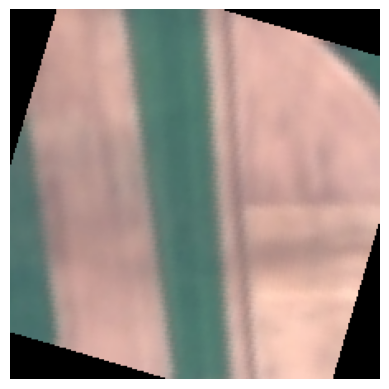

In [22]:
import matplotlib.pyplot as plt
import numpy as np
image = sample["image"]

image = image.permute(1,2,0)

mean = np.array([0.485,0.456,0.406])

std = np.array([0.229,0.224,0.225])

image = image.numpy()*std + mean

image = np.clip(image,0,1)

plt.imshow(image)

plt.axis("off")

# Importing from the src directory and using them

In [23]:
import matplotlib.pyplot as plt
import numpy as np

from PIL import Image

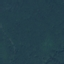

In [24]:
from pathlib import Path

image_path = Path("../data/raw/EuroSAT/Forest")

image_file = next(image_path.glob("*.jpg"))

image = Image.open(image_file)

image

In [25]:
from torchvision import transforms

resize = transforms.Resize((224,224))

horizontal_flip = transforms.RandomHorizontalFlip(p=1)

vertical_flip = transforms.RandomVerticalFlip(p=1)

rotation = transforms.RandomRotation(20)

crop = transforms.RandomResizedCrop(
    size=224,
    scale=(0.9,1.0)
)

color = transforms.ColorJitter(
    brightness=0.15,
    contrast=0.15,
    saturation=0.15,
    hue=0.05
)

In [26]:
images = [

    ("Original", resize(image)),

    ("Horizontal Flip",
     horizontal_flip(resize(image))),

    ("Vertical Flip",
     vertical_flip(resize(image))),

    ("Rotation",
     rotation(resize(image))),

    ("Random Crop",
     crop(image)),

    ("Color Jitter",
     color(resize(image)))

]

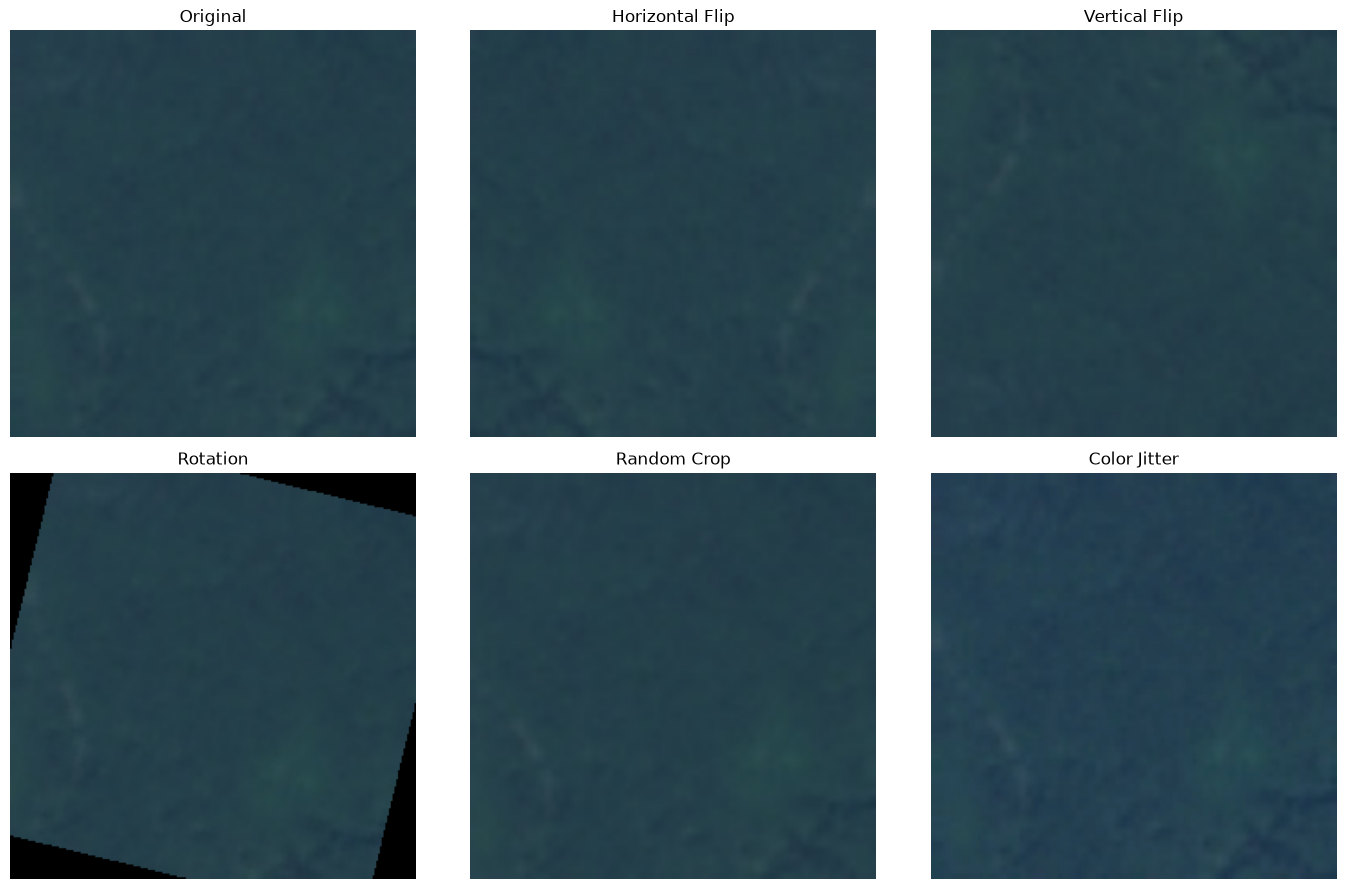

In [27]:
fig, axes = plt.subplots(2,3, figsize=(14,9))

for ax, (title, img) in zip(axes.flatten(), images):

    ax.imshow(img)

    ax.set_title(title)

    ax.axis("off")

plt.tight_layout()

plt.show()

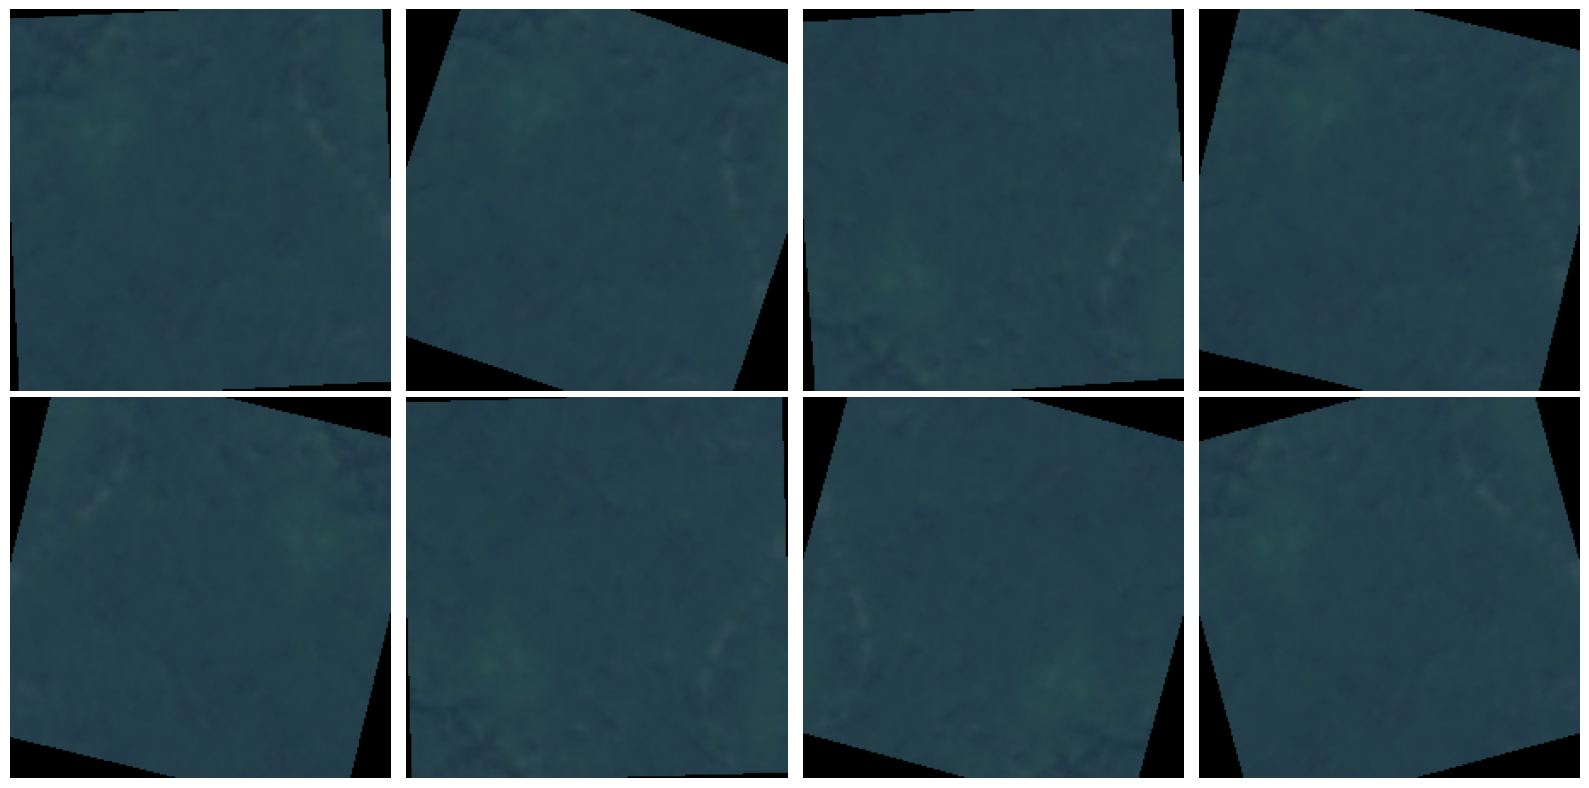

In [28]:
pipeline = train_transform

fig, axes = plt.subplots(2,4, figsize=(16,8))

for ax in axes.flatten():

    img = pipeline(image)

    img = img.permute(1,2,0)

    mean = np.array([0.485,0.456,0.406])

    std = np.array([0.229,0.224,0.225])

    img = img.numpy()

    img = img*std + mean

    img = np.clip(img,0,1)

    ax.imshow(img)

    ax.axis("off")

plt.tight_layout()

In [29]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))